In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"
import keras
import keras.ops as K
from keras.layers import Input, Flatten, Dense

# from keras.models import Sequential
from deel.lip.model import Sequential

from deel.lip.layers import (
    SpectralDense,
    SpectralConv2D,
    ScaledL2NormPooling2D,
    FrobeniusDense,
)
from deel.lip.activations import GroupSort, GroupSort2
from deel.lip.losses import HKR, KR, HingeMargin, MulticlassHKR, MulticlassKR

import numpy as np
import decomon

import sys

# setting path
sys.path.append('..')

from data_processing import load_data, select_data_for_radius_evaluation
from radius_evaluation_tools import compute_binary_certificate, starting_point_dichotomy
from lipschitz_decomon_tools import get_local_maximum, echantillonner_boule_l2_simple, get_local_maximum_multiclass

In [2]:
x_train, x_test, y_train, y_test, y_test_ord = load_data("MNIST")

In [3]:
vanilla_model = keras.models.load_model("/home/aws_install/robustess_project/lip_models/demo0_vanilla_MNIST_channelfirst_False_disj_Neurons.keras")
vanilla_model.compile(
        # decreasing alpha and increasing min_margin improve robustness (at the cost of accuracy)
        # note also in the case of lipschitz networks, more robustness require more parameters.
        loss=MulticlassHKR(alpha=50, min_margin=0.05),
        optimizer=keras.optimizers.Adam(1e-3),
        metrics=["accuracy", MulticlassKR()],)

In [4]:
images, labels, idx_list = select_data_for_radius_evaluation(x_test, y_test_ord, vanilla_model)

In [5]:
pt_choosen = 0
eps=0.2

In [6]:
x = images[pt_choosen:pt_choosen+1].flatten().detach().cpu().numpy()

In [7]:
y_list = [x]
for i in range(100):
    y_list.append(echantillonner_boule_l2_simple(x, eps))

In [8]:
from keras import layers

In [9]:
def create_difference_model(base_model, label, i):
    """
    Crée et retourne un nouveau modèle Keras qui calcule la différence
    entre le logit du 'label' et le logit de 'i'.
    """
    entree_base = base_model.inputs
    sortie_logits_base = base_model.outputs[0]
    # print(label)
    # Définition de la couche Lambda avec la correction et un nom unique
    difference = layers.Lambda(
        # lambda x, current_i=i: x[:, label] - x[:, current_i],
        lambda z: z[:, label:label+1] - z[:, i:i+1], 
        output_shape=(1,),
        # Nom de couche unique : très important !
        name=f"difference_{label}_vs_{i}"
    )(sortie_logits_base)

    # Création du modèle avec un nom unique
    difference_model = keras.Model(
        inputs=entree_base,
        outputs=difference,
        name=f"model_diff_{label}_vs_{i}"
    )
    
    return difference_model

In [10]:
mdl = create_difference_model(vanilla_model, 0, 6)

In [11]:
mdl(images[pt_choosen:pt_choosen+1])

/home/aws_install/miniconda3/envs/k3torchenv/lib/python3.10/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=torch.Size([1, 1, 28, 28]))
  warnings.warn(msg)


tensor([[2.0968]], device='cuda:0', grad_fn=<SubBackward0>)

In [12]:
vanilla_model(images[pt_choosen:pt_choosen+1])

tensor([[ 1.8283, -4.2363, -1.1456, -1.0565, -2.2833, -0.8807, -0.2685, -1.8158,
         -1.0744, -0.5852]], device='cuda:0', grad_fn=<MmBackward0>)

In [13]:
def get_local_maximum_multiclass(x, label, eps, y_list, model, L=1):
    """
    Adaptation du getlocalmaximum au cas multiclasse. On vient borner fgt - fi qui est une fonction racine de 2 lip
    """
    n_classes = model.output_shape[-1]
    list_outputs = list(range(n_classes))
    # print(list_outputs)
    list_outputs.remove(label)
    # print(list_outputs)
    current_min = 1000
    for i in list_outputs:
        print(i)
        difference_model = create_difference_model(model, label, i)

        _, min_one_vs_all =  get_local_maximum(x, 1, eps, y_list, difference_model, L=np.sqrt(2)*L)  
        # stocker x_adv et tester diff model 
        if min_one_vs_all < current_min:
            current_min = min_one_vs_all
    return current_min

In [14]:
def get_local_maximum_multiclass(x, label, eps, y_list, model, L=1):
    """
    Adaptation du getlocalmaximum au cas multiclasse. On vient borner fgt - fi qui est une fonction racine de 2 lip
    """
    n_classes = model.output_shape[-1]
    list_outputs = list(range(n_classes))
    # print(list_outputs)
    list_outputs.remove(label)
    # print(list_outputs)
    print(K.argsort(model(images[pt_choosen:pt_choosen+1]))[:,-2])
    difference_model = create_difference_model(model, label, K.argsort(model(images[pt_choosen:pt_choosen+1]))[:,-2])

    _, min_one_vs_all, _ =  get_local_maximum(x, 1, eps, y_list, difference_model, L=np.sqrt(2)*L)   
    
    return min_one_vs_all

In [15]:
d_up = starting_point_dichotomy(pt_choosen, images, labels).detach().cpu().numpy()

In [16]:
ep = d_up/2

In [21]:
ep = 0.5

In [22]:
# ep = (d_up+d_low)/2
print(ep)
y_list = [x]
for i in range(50):
    y_list.append(echantillonner_boule_l2_simple(x, ep))

0.5


tensor([6], device='cuda:0', dtype=torch.int32)


/home/aws_install/miniconda3/envs/k3torchenv/lib/python3.10/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 1, 28, 28))
  warnings.warn(msg)


empirical max values [-17.689326901301936, -17.6892620303301, -17.689142916700956]
empirical min values [-17.69287920791879, -17.692599187063166, -17.692351399411113]
Optimization terminated successfully    (Exit mode 0)
            Current function value: -17.69801007696359
            Iterations: 6
            Function evaluations: 17
            Gradient evaluations: 6


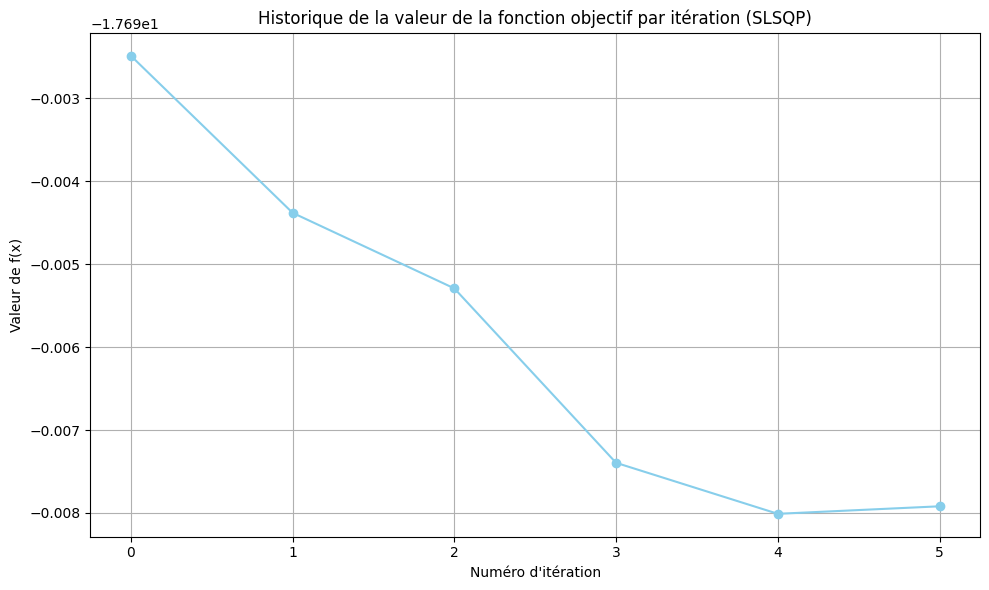

In [23]:
min = get_local_maximum_multiclass(x, labels[pt_choosen], ep, y_list, vanilla_model)
# stocker cas qui ne fonctionnent pas (x,eps,yi)

In [39]:
dico = {}
dico["point"] = pt_choosen
dico["eps"] = ep
dico["list_points"] = y_list

In [40]:
import pickle

In [41]:
with open("dico2.pkl", "wb") as f:
    pickle.dump(dico, f)

In [42]:
with open('dico2.pkl', 'rb') as f: # 'rb' pour "read binary"
    dictionnaire_charge_pickle = pickle.load(f)

on a flabel-fi sqrt(2)lip donc en fait pour trouver le plus petit, on a juste à faire top1 - top2 et pas tester toutes les sorties

In [19]:
min

0.11689281463623047

In [20]:
import sys
sys.path.append('..')
from radius_evaluation_tools import single_compute_relaxation_radius_multiclass

In [21]:
pt_choosen = 100

In [22]:
single_compute_relaxation_radius_multiclass(pt_choosen, images, labels, vanilla_model, 20)

tensor([6], device='cuda:0', dtype=torch.int32)


KeyboardInterrupt: 